In [1]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

In [3]:
#Loading and Analyzing Dataset
df = pd.read_csv(r"C:\Users\fizha\Downloads\Loan_Approval_GUI\loan_approval_dataset.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [6]:
#Removing Space from Column Names
df.columns = df.columns.str.strip()
#Checking Columns Types for Applying Label Encoding
print(df.columns)
#Checking Loan Status Values
print("Loan Status Values: ",df['loan_status'].unique())

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
Loan Status Values:  [' Approved' ' Rejected']


In [7]:
#Label Encoding for (Categorical Columns)
le = LabelEncoder()

categorical_cols = ['education','self_employed','loan_status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
#Checking Datatypes for ensuring Label Encoding
print(df.dtypes)

loan_id                     int64
no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object


In [9]:
#Feature Engineering
df['income_loan_ratio'] = df['income_annum'] / df['loan_amount']

df['total_assets'] = (df['residential_assets_value']+ df['commercial_assets_value']+ df['luxury_assets_value']+ df['bank_asset_value'])

df['loan_per_term'] = df['loan_amount'] / df['loan_term']

In [10]:
print(df.head())

   loan_id  no_of_dependents  education  self_employed  income_annum  \
0        1                 2          0              0       9600000   
1        2                 0          1              1       4100000   
2        3                 3          0              0       9100000   
3        4                 3          0              0       8200000   
4        5                 5          1              1       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value  \
0                 17600000             22700000           8000000   
1                  2

In [15]:
#Checking Correlation Between Features
correlation = df.corr()['loan_status'].sort_values(ascending=False)

print(correlation)

loan_status                 1.000000
loan_term                   0.113036
income_loan_ratio           0.086540
no_of_dependents            0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
total_assets                0.011281
bank_asset_value            0.006778
education                   0.004918
self_employed              -0.000345
commercial_assets_value    -0.008246
loan_amount                -0.016150
loan_id                    -0.017685
loan_per_term              -0.125542
cibil_score                -0.770518
Name: loan_status, dtype: float64


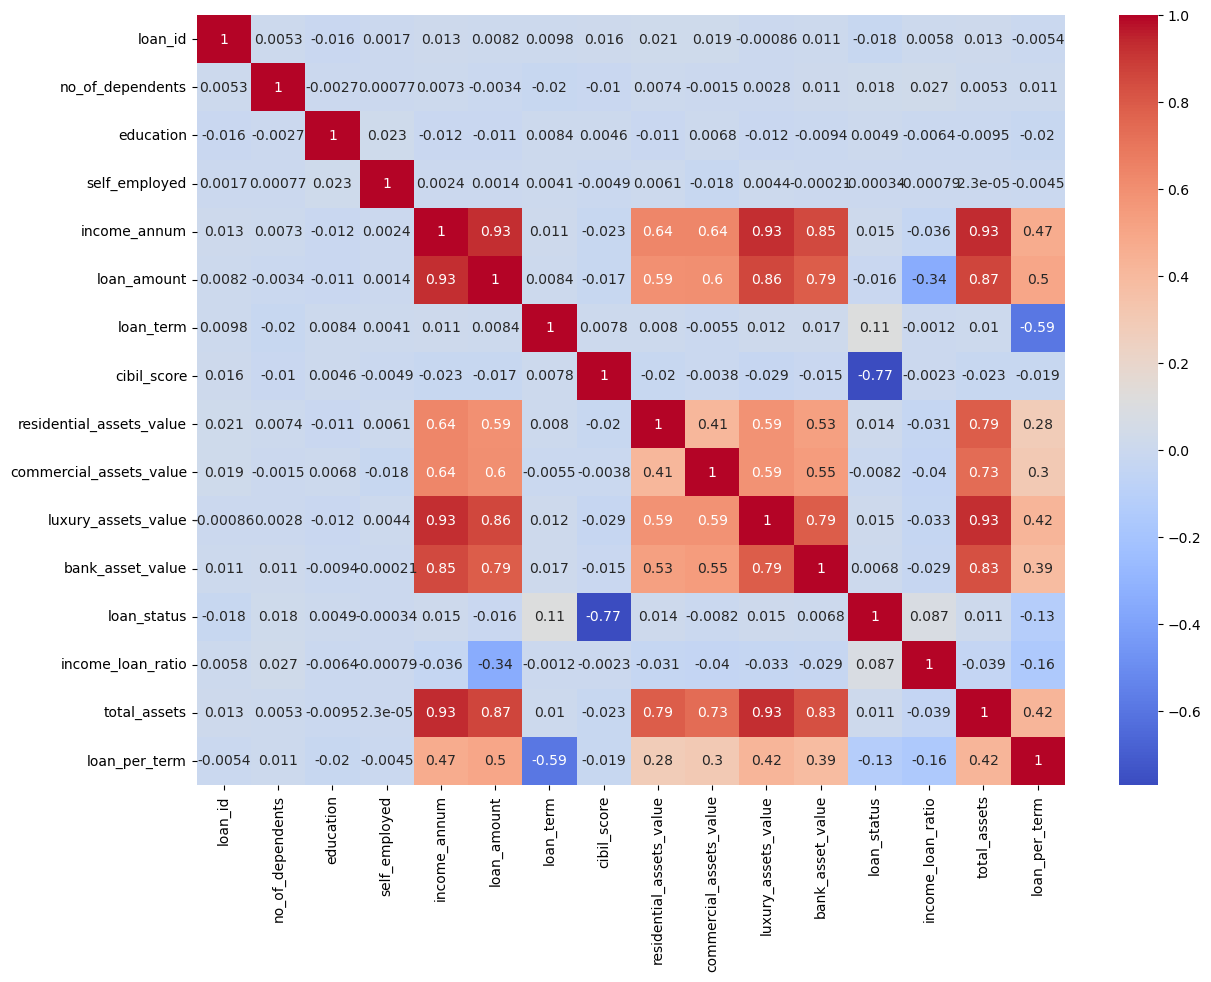

In [16]:
#Checking Relationship between Features by Ploting Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

In [15]:
#Feature Seleciton
selected_features = ['cibil_score','loan_term','income_loan_ratio','loan_per_term','income_annum','loan_amount','total_assets','no_of_dependents']

In [16]:
#Target Columns
X = df[selected_features]

y = df['loan_status']

In [17]:
#Scaling 
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
#Splitting for Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
#Applying Multiple Models for Comparison
models = {
    'Logistic Regression': LogisticRegression(),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),
    
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    
    'SVM': SVC(
        kernel='rbf'
    ),
    
    'Naive Bayes': GaussianNB()
}

In [20]:
#Training Multiple Models
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9215456674473068
Decision Tree Accuracy: 0.9964871194379391
KNN Accuracy: 0.927400468384075
SVM Accuracy: 0.9637002341920374
Naive Bayes Accuracy: 0.9473067915690867


In [21]:
for name, model in models.items():
    
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    
    print(name)
    print("Train Accuracy:", train_accuracy)
    print("Test Accuracy:", test_accuracy)
    print("---------------------------")

Logistic Regression
Train Accuracy: 0.9297218155197657
Test Accuracy: 0.9215456674473068
---------------------------
Decision Tree
Train Accuracy: 0.9988286969253294
Test Accuracy: 0.9964871194379391
---------------------------
KNN
Train Accuracy: 0.9689604685212299
Test Accuracy: 0.927400468384075
---------------------------
SVM
Train Accuracy: 0.9707174231332357
Test Accuracy: 0.9637002341920374
---------------------------
Naive Bayes
Train Accuracy: 0.9464128843338214
Test Accuracy: 0.9473067915690867
---------------------------


In [24]:
#Ensemble Models to Improve Prediction Stability
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

ensemble_model = VotingClassifier(
    estimators=[
        ('svm', SVC(probability=True)),
        ('nb', GaussianNB()),
        ('lr', LogisticRegression())
    ],
    voting='soft'
)

In [25]:
ensemble_model.fit(X_train, y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [26]:
y_pred = ensemble_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Ensemble Accuracy:", accuracy)

Ensemble Accuracy: 0.9461358313817331


In [28]:
train_accuracy = ensemble_model.score(X_train, y_train)
print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.9563689604685213


In [30]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Classification Report: \n",classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       536
           1       0.92      0.93      0.93       318

    accuracy                           0.95       854
   macro avg       0.94      0.94      0.94       854
weighted avg       0.95      0.95      0.95       854


Confusion Matrix:
[[511  25]
 [ 21 297]]


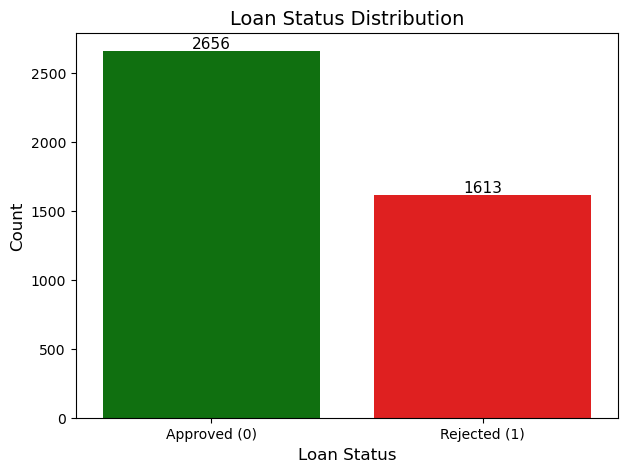

In [31]:
#TARGET VARIABLE DISTRIBUTION (Approved vs Rejected)
plt.figure(figsize=(7,5))

ax = sns.countplot(x='loan_status',hue='loan_status',data=df,palette=['green', 'red'],legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Approved (0)','Rejected (1)'])

plt.title("Loan Status Distribution",fontsize=14)
plt.xlabel("Loan Status",fontsize=12)
plt.ylabel("Count",fontsize=12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (   p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='bottom',
        fontsize=11
    )
plt.show()

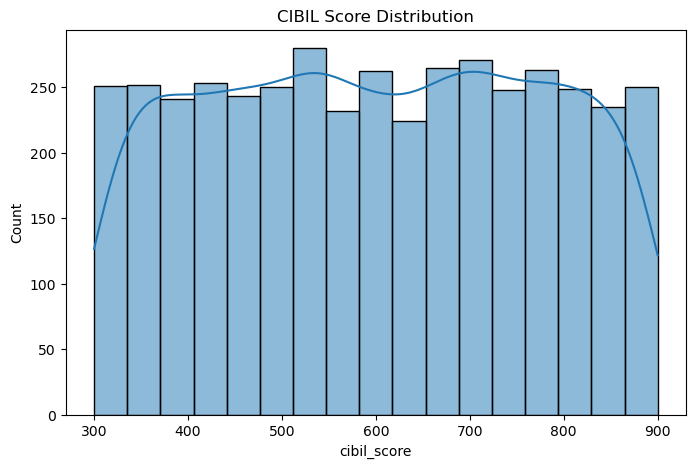

In [43]:
#Cibil Score Histogram Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['cibil_score'], kde=True)

plt.title("CIBIL Score Distribution")
plt.show()

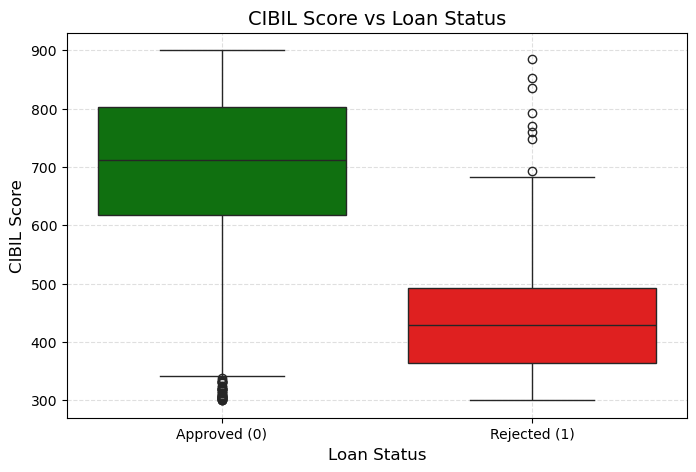

In [32]:
#BOXPLOT FOR CLASS DIFFERENCES

plt.figure(figsize=(8,5))

ax = sns.boxplot(x='loan_status',y='cibil_score',hue='loan_status',data=df,palette=['green', 'red'],legend=False)
ax.set_xticks([0,1])
ax.set_xticklabels(['Approved (0)','Rejected (1)'])

plt.title("CIBIL Score vs Loan Status",fontsize=14)
plt.xlabel("Loan Status",fontsize=12)
plt.ylabel("CIBIL Score",fontsize=12)

plt.grid(linestyle='--',alpha=0.4)
plt.show()

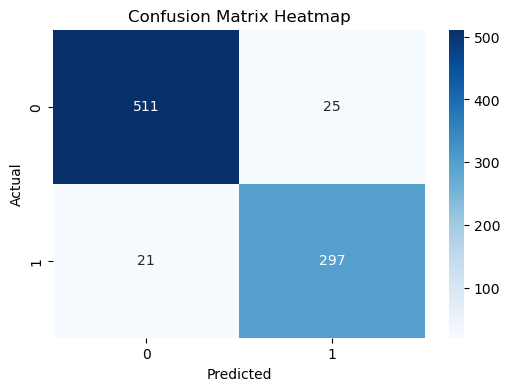

In [50]:
#Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

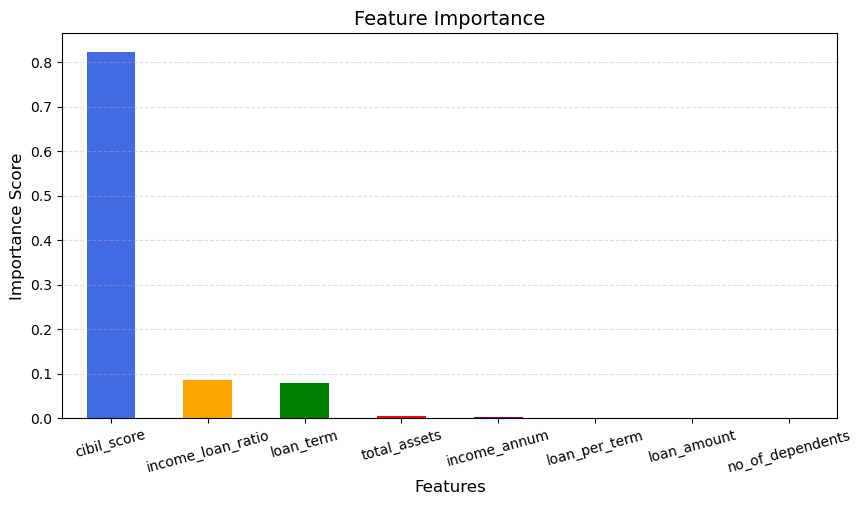

In [35]:
#FEATURE IMPORTANCE GRAPH
feature_importance = pd.Series(models['Decision Tree'].feature_importances_,index=selected_features)
feature_importance = feature_importance.sort_values(ascending=False)
plt.figure(figsize=(10,5))
feature_importance.plot(kind='bar',color=['royalblue','orange','green','red','purple','brown','pink','gray'])

plt.title("Feature Importance",fontsize=14)
plt.xlabel("Features",fontsize=12)
plt.ylabel("Importance Score",fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.xticks(rotation=15)
plt.show()

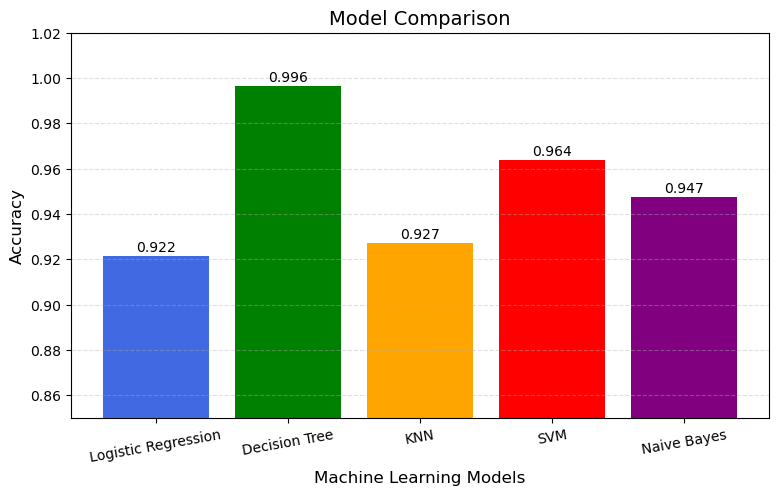

In [33]:
#MODEL COMPARISON BAR CHART
model_names = ['Logistic Regression','Decision Tree','KNN','SVM','Naive Bayes']
accuracies = [0.9215,0.9964,0.9274,0.9637,0.9473]

plt.figure(figsize=(9,5))
bars = plt.bar(model_names,accuracies,color=['royalblue','green','orange','red','purple'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,yval + 0.002,round(yval, 3),ha='center',fontsize=10)

plt.ylabel("Accuracy",fontsize=12)
plt.xlabel("Machine Learning Models",fontsize=12)
plt.title("Model Comparison",fontsize=14)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.xticks(rotation=10)
plt.ylim(0.85, 1.02)
plt.show()

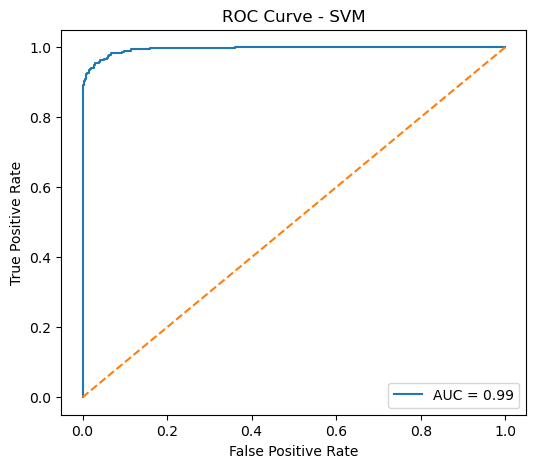

In [40]:
#SVM ROC Curve
from sklearn.metrics import roc_curve, auc
svm_model = models['SVM']

y_prob = svm_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

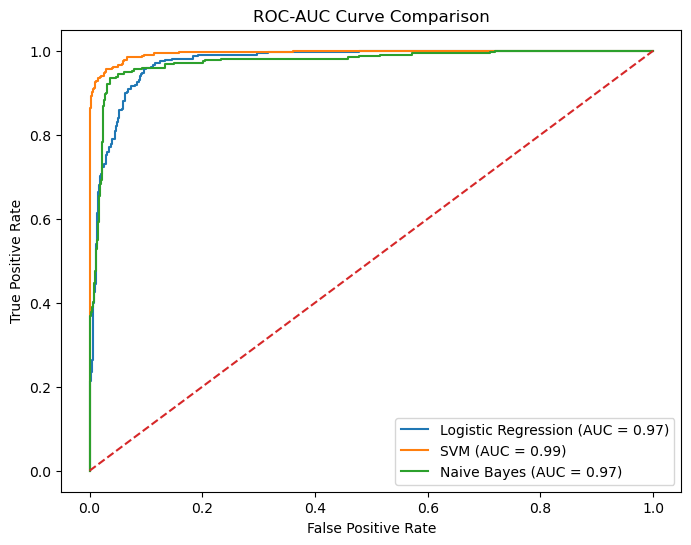

In [45]:
#MULTIPLE ROC-AUC CURVES (SVM, Logistic Regression, Naive Bayes)
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

lr_model = models['Logistic Regression']
lr_prob = lr_model.predict_proba(X_test)[:,1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = auc(lr_fpr, lr_tpr)

plt.plot(lr_fpr,lr_tpr,label=f'Logistic Regression (AUC = {lr_auc:.2f})')

svm_model = models['SVM']
svm_prob = svm_model.decision_function(X_test)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
svm_auc = auc(svm_fpr, svm_tpr)

plt.plot(svm_fpr,svm_tpr,label=f'SVM (AUC = {svm_auc:.2f})')

nb_model = models['Naive Bayes']
nb_prob = nb_model.predict_proba(X_test)[:,1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
nb_auc = auc(nb_fpr, nb_tpr)

plt.plot(nb_fpr,nb_tpr,label=f'Naive Bayes (AUC = {nb_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.show()

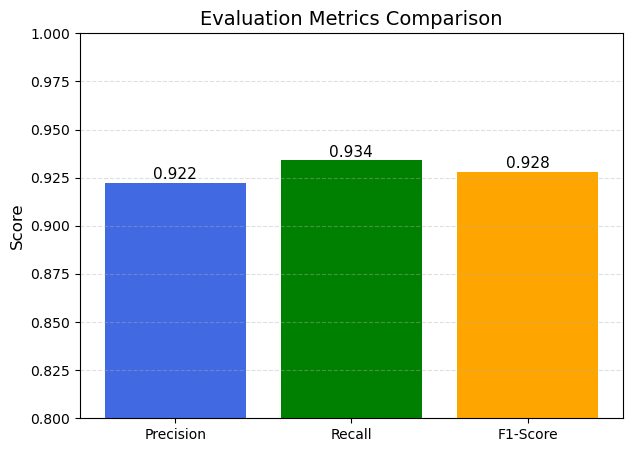

In [48]:
#PRECISION, RECALL & F1-SCORE COMPARISON
from sklearn.metrics import (precision_score,recall_score,f1_score)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
metrics = ['Precision','Recall','F1-Score']
values = [precision,recall,f1]

plt.figure(figsize=(7,5))

bars = plt.bar(metrics,values,color=['royalblue','green','orange'])
for bar in bars:    
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,yval + 0.002,round(yval, 3),ha='center',fontsize=11)

plt.title("Evaluation Metrics Comparison",fontsize=14)
plt.ylabel("Score",fontsize=12)
plt.ylim(0.8, 1.0)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.show()

In [44]:
df.to_csv('final_processed_loan_dataset.csv', index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [53]:
!pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1


In [54]:
import joblib

#Saving Ensemble Model
joblib.dump(ensemble_model,'loan_model.pkl')

#Saving Scaler
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [55]:
import joblib

#Saving Decision Tree Model
joblib.dump(
    models['Decision Tree'],
    'decision_tree.pkl'
)

['decision_tree.pkl']